### 3. Atividades Práticas Experimentais

### 3.1. Correção de Ponto Branco (White Point Correction - 4.1.11)

A correção de ponto branco ajusta a iluminação para que objetos brancos pareçam brancos sob diferentes fontes de luz. Usaremos a transformação de von Kries:
$C_{new} = C_{old} \cdot (W_{target} / W_{source})$.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

def white_point_correction(img, sourcewp, targetwp):
    # img escala [0, 1]
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)


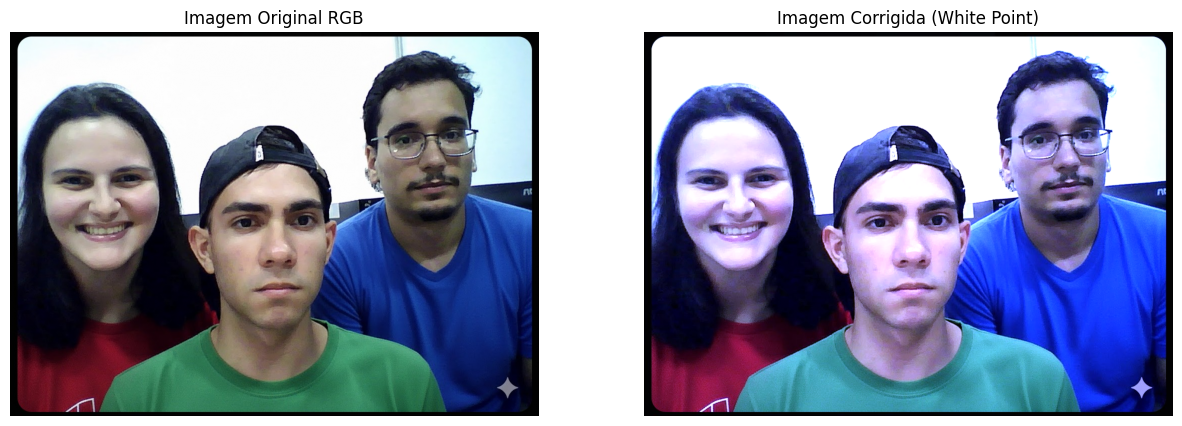

In [ ]:
# Exemplo: Corrigindo de uma luz quente (amarelada) para D65 (luz do dia)
img = cv2.imread('static/foto-grupo.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) /255.0

# Simplificação: canais R, G, B
source_wp = np.array([0.8, 0.8, 0.5])
target_wp = np.array([1.0, 1.0, 1.0])
corrected_img = white_point_correction(img_rgb, source_wp, target_wp)

# Mostra a imagem corrigida
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(img_rgb) # Display the original image (normalized)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(corrected_img)
plt.title('Imagem Corrigida (White Point)')
plt.axis('off')

plt.show()

### 3.2. Transformação XYZ para RGB e Correção Gama (4.1.12 e 4.1.13)

O espaço $XYZ$ é independente de dispositivo, mas para exibição em monitores, precisamos converter para $RGB$ e aplicar a lei de potência (Gama).

In [ ]:
def xyz_to_rgb_gamma(xyz_img):
    # Matriz de conversão linear XYZ para RGB (exemplo para D65)
    matrix = np.array([[3.2406, -1.5372, -0.4986],
                       [-0.9689, 1.8758, 0.0415],
                       [0.0557, -0.2040, 1.0570]])

    rgb_linear = xyz_img @ matrix.T
    rgb_linear = np.clip(rgb_linear, 0, 1)

    # Correção Gama (4.1.13): sRGB standard
    # Aproximação: C = 1.055 * L^(1/2.4) - 0.055
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return gamma_corrected

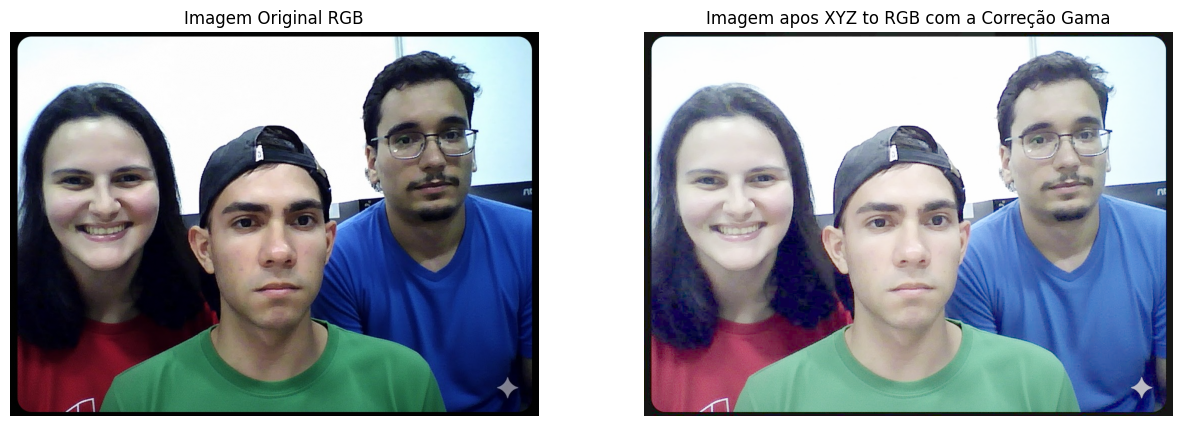

In [ ]:
# APLICANDO A CORREÇÃO GAMA EM UMA IMAGEM

# É necessário ter a imagem RGB no formato correto para a conversão.
# Como `img_rgb` foi obtida de `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) / 255.0`,
# ela já está no formato RGB e normalizada.
# A função cvtColor do OpenCV, que converte de RGB para XYZ,
# espera valores float32 e valores entre 0 e 1 para tipos CV_32F.

img_rgb_float32 = img_rgb.astype(np.float32)
img_xyz = cv2.cvtColor(img_rgb_float32, cv2.COLOR_RGB2XYZ)

# Aplicando a funcao xyz_to_rgb_gamma :
gamma_corrected_xyz_to_rgb = xyz_to_rgb_gamma(img_xyz)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_corrected_xyz_to_rgb)
plt.title('Imagem apos XYZ to RGB com a Correção Gama')
plt.axis('off')

plt.show()

### 3.3. O Modelo CIELAB ($L^*a^*b^*$) (4.1.14)

Este modelo é projetado para ser perceptualmente uniforme. $L^*$ representa a luminosidade, enquanto $a^*$ e $b^*$ são as dimensões de oponência de cor.

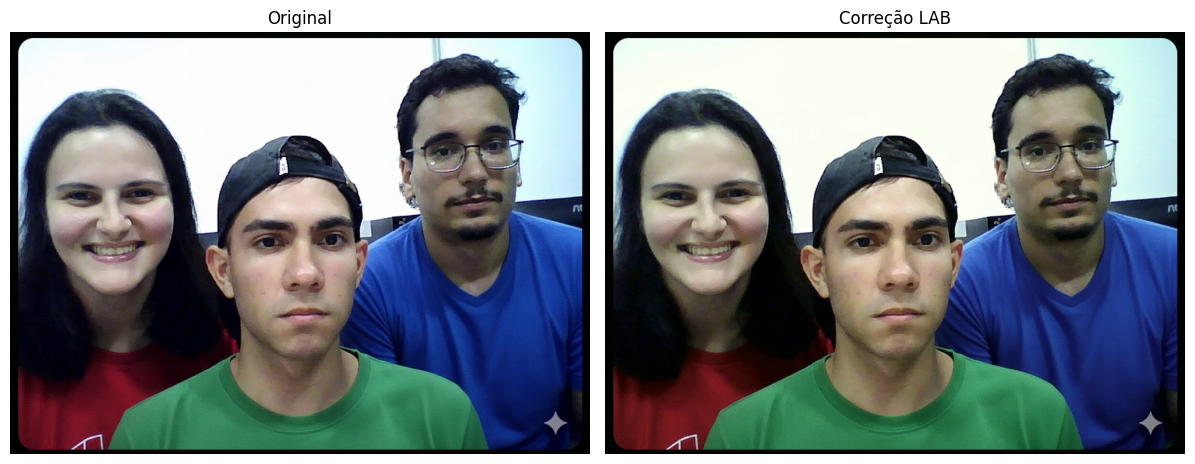

In [ ]:
def white_point_correction_lab(img_rgb):
    """
    Correção de white point no espaço LAB usando Gray World Assumption.
    Zera a média de a* e b* para remover dominante de cor.
    """
    img_uint8 = (np.clip(img_rgb, 0, 1) * 255).astype(np.uint8)

    # RGB -> LAB
    img_lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB).astype(np.float32)

    L, a, b = cv2.split(img_lab)

    # Subtrai a média de a* e b* (neutro = média 128 no OpenCV)
    a -= (a.mean() - 128)
    b -= (b.mean() - 128)

    # Reagrupa
    img_lab_corr = cv2.merge([
        np.clip(L, 0, 255).astype(np.uint8),
        np.clip(a, 0, 255).astype(np.uint8),
        np.clip(b, 0, 255).astype(np.uint8)
    ])

    img_corr_rgb = cv2.cvtColor(img_lab_corr, cv2.COLOR_LAB2RGB)
    return img_corr_rgb / 255.0


# --- Main ---
img = cv2.imread('static/foto-grupo.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

# LAB
corrected_lab = white_point_correction_lab(img_rgb)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 2); plt.imshow(img_rgb);        plt.title('Original');       plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(corrected_lab);  plt.title('Correção LAB');   plt.axis('off')
plt.tight_layout()
plt.show()

### 3.4. Cores Dependentes de Câmera: HSV e sRGB (4.2.3)

O $HSV$ (Hue, Saturation, Value) é uma transformação não linear do $RGB$ que facilita a segmentação de objetos por cor, independente da intensidade luminosa.

Diferente do RGB, onde uma cor "azul" pode ter valores muito diferentes dependendo do brilho, no HSV o azul está concentrado em uma faixa específica do canal **H** (Hue).


In [ ]:
# Segmentação simples usando HSV
# Observe a geração da máscara azul com a função inRange()

hsv = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2HSV)
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([130, 255, 255])
mask = cv2.inRange(hsv, lower_blue, upper_blue)

In [ ]:
def segmentar_por_cor(img_bgr):
    # 1. Converter para HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # 2. Definir o intervalo da cor desejada (Exemplo: Verde)
    # No OpenCV: H vai de 0 a 179, S e V de 0 a 255
    verde_baixo = np.array([35, 50, 50])
    verde_alto = np.array([85, 255, 255])

    # 3. Criar uma máscara binária
    mask = cv2.inRange(hsv, verde_baixo, verde_alto)

    # 4. Aplicar a máscara na imagem original
    resultado = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    return mask, resultado

In [ ]:
# Apresentação das etapas
# Obs. assumindo que a imagem 'img_bgr' já foi previamente gerada:
if 'img' in locals() and img is not None:
    mask_hsv, segmented_object_hsv = segmentar_por_cor(img)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask_hsv, cmap='gray')
    plt.title('HSV Mask (Green)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(segmented_object_hsv, cv2.COLOR_BGR2RGB))
    plt.title('Objecto Segmentado (HSV)')
    plt.axis('off')

    plt.show()
else:
    print("Error: 'img_bgr' is not defined. Please ensure the image is loaded first.")

Error: 'img_bgr' is not defined. Please ensure the image is loaded first.


### 3.5. Modelo $YCbCr$ (4.3.4)

Essencial para compressão de vídeo (MPEG, JPEG). Ele separa a Luminância ($Y$) da Crominância ($Cb$ e $Cr$).

A transformação padrão (BT.601) segue:


$$Y = 0.299R + 0.587G + 0.114B$$

$$Cb = 0.564(B - Y)$$

$$Cr = 0.713(R - Y)$$

In [ ]:
def rgb_to_ycbcr(rgb_img):
    # Coeficientes do livro (Seção 4.3.4)
    transform_mat = np.array([[0.299, 0.587, 0.114],
                              [-0.1687, -0.3313, 0.5],
                              [0.5, -0.4187, -0.0813]])
    # Ajuste de offset para Cb e Cr (normalmente 128 em 8 bits)
    ycbcr = rgb_img @ transform_mat.T
    ycbcr[:,:,1:] += 0.5
    return np.clip(ycbcr, 0, 1)

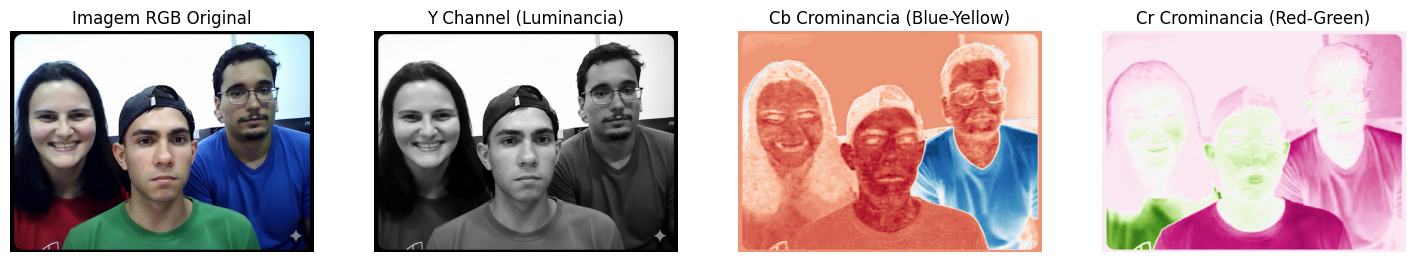

In [ ]:
# Apresentação dos canais Y, Cb, Cr:
# Obs. assumindo que a imagem 'img_rgb' já foi previamente gerada:
if 'img_rgb' in locals() and img_rgb is not None:
    # Aplicar a função rgb_to_ycbcr
    ycbcr_img = rgb_to_ycbcr(img_rgb)

    # Separar os canais Y, Cb e Cr
    Y_channel = ycbcr_img[:, :, 0]
    Cb_channel = ycbcr_img[:, :, 1]
    Cr_channel = ycbcr_img[:, :, 2]

    # Plotar a imagem original e os canais separados
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem RGB Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(Y_channel, cmap='gray')
    plt.title('Y Channel (Luminancia)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(Cb_channel, cmap='RdBu') # Red-Blue para Cb
    plt.title('Cb Crominancia (Blue-Yellow)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(Cr_channel, cmap='PiYG') # Pink-Yellow-Green para Cr
    plt.title('Cr Crominancia (Red-Green)')
    plt.axis('off')

    plt.show()
else:
    print("Erro: 'img_rgb' não está definida. Por favor, carregue a imagem RGB primeiro.")

In [ ]:
def plot_color_decomposition(img_path):
    # Carregar imagem original (BGR) e converter para RGB para o Matplotlib
    bgr = cv2.imread(img_path)
    if bgr is None:
        print("Erro ao carregar a imagem.")
        return
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # 1. Transformação para LAB (Seção 4.1.14)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab)
    l_chan, a_chan, b_chan = cv2.split(lab)

    # 2. Transformação para YCbCr (Seção 4.3.4)
    ycbcr = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb) # OpenCV usa YCrCb por padrão
    y_chan, cr_chan, cb_chan = cv2.split(ycbcr)

    # Configuração do Plot
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # Linha 1: Original e Espaço LAB
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("Original (RGB)")
    axes[0, 1].imshow(l_chan, cmap='gray')
    axes[0, 1].set_title("LAB: Canal L* (Luminosidade)")
    axes[0, 2].imshow(a_chan, cmap='RdYlGn_r') # Red-Green para o eixo 'a'
    axes[0, 2].set_title("LAB: Canal a* (Verde-Vermelho)")

    # Linha 2: Continuação LAB e Espaço YCbCr
    axes[1, 0].imshow(b_chan, cmap='YlGnBu_r') # Yellow-Blue para o eixo 'b'
    axes[1, 0].set_title("LAB: Canal b* (Azul-Amarelo)")
    axes[1, 1].imshow(y_chan, cmap='gray')
    axes[1, 1].set_title("YCbCr: Canal Y (Luma)")
    axes[1, 2].imshow(cb_chan, cmap='jet')
    axes[1, 2].set_title("YCbCr: Canal Cb (Crominância Azul)")

    # Linha 3: Canal Cr e histogramas para análise
    axes[2, 0].imshow(cr_chan, cmap='jet')
    axes[2, 0].set_title("YCbCr: Canal Cr (Crominância Vermelha)")

    # Histograma de Luminância para comparar L* vs Y
    axes[2, 1].hist(l_chan.ravel(), bins=256, color='black', alpha=0.5, label='L*')
    axes[2, 1].hist(y_chan.ravel(), bins=256, color='blue', alpha=0.3, label='Y')
    axes[2, 1].set_title("Histograma: L* (LAB) vs Y (YCbCr)")
    axes[2, 1].legend()

    # Desativar eixos para as imagens
    for i in range(3):
        for j in range(3):
            if not (i == 2 and j == 1):
                axes[i, j].axis('off')

    plt.show()


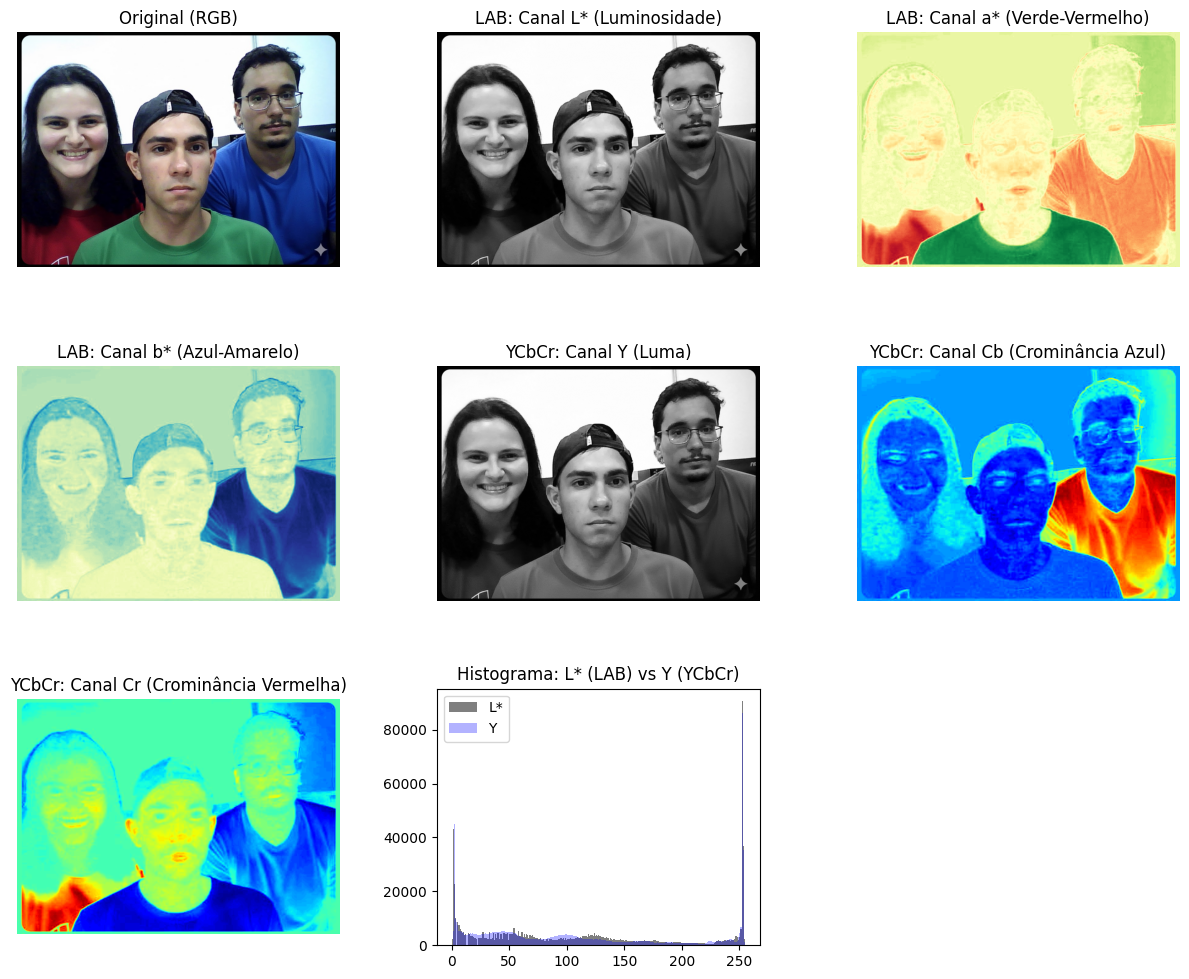

In [ ]:
plot_color_decomposition('static/foto-grupo.jpeg')

### Captura webcam e aplicação de correções white point e gamma

In [ ]:
source_wp = np.array([0.8, 0.8, 0.5])
target_wp = np.array([1.0, 1.0, 1.0])

cap = cv2.VideoCapture(0)
print("Pressione [s] para salvar as imagens ou [q] para sair.")

if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # captura dos frames
    ret, frame = cap.read()
    # se frame está lendo corretamente, ret é True.
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    frame_xyz = cv2.cvtColor(frame, cv2.COLOR_BGR2XYZ).astype(np.float32) / 255.0

     # 2. Aplicar suas funções
    img_white_point = white_point_correction(frame_rgb, source_wp, target_wp)
    img_gamma = xyz_to_rgb_gamma(frame_xyz)

    # 3. criando a junção das correções
    img_corrigida = np.clip(img_white_point, 0.0, 1.0)
    img_wp_xyz = cv2.cvtColor((img_corrigida * 255).astype(np.uint8), cv2.COLOR_RGB2XYZ).astype(np.float32) / 255.0
    img_final = np.clip(xyz_to_rgb_gamma(img_wp_xyz), 0.0, 1.0)


    # 4. Converter de volta para BGR e Uint8 para o OpenCV exibir/salvar
    # Invertemos para BGR (RGB -> BGR) para o imshow não trocar as cores
    res_wp = cv2.cvtColor((img_corrigida * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    res_gamma = cv2.cvtColor((img_gamma * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    res_final = cv2.cvtColor((img_final * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

    # 5. montando as janelas
    cv2.imshow('original', frame)
    cv2.imshow('White point', res_wp)
    cv2.imshow('Gamma', res_gamma)
    cv2.imshow('White Point + Gamma', res_final)

    key = cv2.waitKey(1)

    if key == ord('q'):
        break
    if key == ord('s'):
        cv2.imwrite('static/original.jpg', frame)
        cv2.imwrite('static/white_point.jpg',res_wp)
        cv2.imwrite('static/gama.jpg', res_gamma)
        cv2.imwrite('static/wp_gamma.jpg', res_final)

#6. fechando as janelas
cap.release()
cv2.destroyAllWindows()

Pressione [s] para salvar as imagens ou [q] para sair.


QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: C

### Captura webcam e aplicação de HSV (TO DO: arrumar o loop infinito que está dando no codigo abaixo)

In [ ]:
cap = cv2.VideoCapture(0)
print("Pressione [s] para salvar as imagens ou [q] para sair.")

if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower = np.array([35, 50, 50])
    upper = np.array([85, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)
    segmento = cv2.bitwise_and(frame, frame, mask=mask)
    combined = np.hstack((frame, segmento))

    cv2.imshow("Original | Segmentado", combined)
    cv2.imshow("Mascara", mask)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break

    if key == ord('s'):
        cv2.imwrite('static/original.jpg', frame)
        cv2.imwrite('static/mascara.jpg', mask)
        cv2.imwrite('static/segmento.jpg', segmento)
        print("Imagens salvas em static/")

# release capture
cap.release()
cv2.destroyAllWindows()

Pressione [s] para salvar as imagens ou [q] para sair.


QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/fabricio/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: C

### Comparacao de Luminosidade

In [ ]:
img_rgb = cv2.cvtColor(cv2.imread('static/foto-grupo.jpeg'), cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Imagem Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(L,cmap='gray')
plt.title("L* (LAB)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(Y,cmap='gray')
plt.title("Y (YCbCr)")
plt.axis('off')

plt.show()

### Efeito Gama

In [ ]:
img = cv2.imread('static/foto-grupo.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

gamma = 2.2
img_gamma = np.power(img_rgb, gamma)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_gamma)
plt.title("Gamma = 2.2")
plt.axis('off')

plt.show()

### Filtro de Cor

In [ ]:
img = cv2.imread('static/foto-grupo.jpeg')

ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
ycrcb[:,:,1] = 128  # Cr
ycrcb[:,:,2] = 128  # Cb
gray_img = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(gray_img, cv2.COLOR_BGR2RGB))
plt.title("Sem cor (YCbCr)")
plt.axis('off')

plt.show()

### Desafio das cores



In [ ]:
img = cv2.imread('static/cores.jpeg')
img_rgb = #RGB
R = img_rgb[:,:,0]
G = img_rgb[:,:,1]
B = img_rgb[:,:,2]

#p/ detectar vermelho
mask = (R > 150) & (G < 100) & (B < 100)
resultado = img_rgb.copy()
resultado[~mask] = 0

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(resultado)
plt.title("Segmentação RGB")
plt.axis('off')

plt.show()

#HSV
lower1 = np.array([0, 50, 50])
upper1 = np.array([10, 255, 255])

lower2 = np.array([170, 50, 50])
upper2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower1, upper1)
mask2 = cv2.inRange(hsv, lower2, upper2)

mask = mask1 + mask2

resultado = cv2.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Segmentação HSV")
plt.axis('off')

plt.show()

RGB: mais dificil de ajustar, problemas com sombras e mais vulneravel com brilho

HSV: mais simples de ajustar, e melhor com sombras/brilho


### a) Sobre Ponto Branco e Constância de Cor
A correção de ponto branco é considerada uma transformação de adaptação cromática porque tenta reproduzir no computador um comportamento natural da visão humana. Nossos olhos conseguem se adaptar a diferentes tipos de iluminação,como luz do sol, lampadas amareladas ou ambientes mais frios, e ainda assim percebemos objetos brancos como brancos.
No processamento de imagens, isso ja não acontece automaticamente. Cada fonte de luz altera as cores capturadas pela câmera. A correção de ponto branco atua ajustando os canais de cor da imagem para compensar a iluminação, fazendo com que as cores fiquem mais próximas do que seriam vistas em condições neutras. Por isso, ela é chamada de adaptação cromática pois ela “adapta” a imagem à iluminação desejada.

---

### b) Espaços Independentes vs Dependentes (XYZ vs sRGB)
A principal diferença prática entre o espaço CIE XYZ e o sRGB está na sua finalidade. O XYZ é um modelo matemático padronizado, criado para representar cores de forma universal, independente de qualquer dispositivo. Já o sRGB é um padrão desenvolvido especificamente para exibição em telas como monitores, celulares e tvs.
Isso significa que o XYZ é usado como um intermediário para cálculos e conversões, enquanto o sRGB é usado para mostrar a imagem ao usuário. Nao exibimos imagens diretamente em XYZ porque os dispositivos não são projetados para isso. Eles trabalham com sinais RGB, que controlam diretamente a intensidade de vermelho, verde e azul na tela. logo, qualquer imagem em xyz precisa ser convertida para sRGB antes de ser exibida corretamente.

---

### c) A Necessidade da Correção Gama
A correção gama eh necessaria porque existe uma diferença entre a forma como os dispositivos exibem luz e a forma como o olho humano percebe essa luz e sem essa correção, a imagem exibida ficaria visualmente incorreta, principalmente nas regiões mais escuras.
Se a correção gama fosse omitida, as sombras da imagem ficariam muito mais escuras do que deveriam, causando perda de detalhes. Áreas que deveriam apresentar textura ou variações suaves de intensidade acabariam ficando muito escuras. Isso prejudica a interpretação da imagem.
Com a correção gama, essas regiões são ajustadas para que os níveis de brilho fiquem corretos, permitindo uma visualização próxima da percepção humana.

---

### d) Percepção Humana e o Modelo CIELAB
O modelo CIELAB é chamado de perceptualmente uniforme porque ele foi projetado para que diferenças numéricas entre cores correspondam melhor às diferenças percebidas pelo olho humano.
Isso é importante porque em outros modelos,como o RGB, uma mesma variação numérica pode resultar em diferenças visuais muito distintas. No LAB,essa relação é mais consistente: pequenas mudanças nos valores indicam pequenas mudanças visuais, enquanto grandes diferenças indicam mudanças mais perceptíveis.
Essa característica torna o LAB muito útil em aplicações que envolvem comparação de cores, análise de similaridade e correções visuais mais precisas.

---

### e) Engenharia de Vídeo e YCbCr
Durante a visualização dos canais Y, Cb e Cr, é possível perceber que o canal Y (iuminância) contém mais detalhes da imagem, enquanto os canais Cb e Cr (crominância) parecem mais suaves ou borrados. isso acontece porque o olho humano é muito mais sensível a variações de brilho do que a variações de cor.
Os sistemas de compressão de imagem e vídeo aproveitam essa característica para reduzir o tamanho dos arquivos. Eles mantêm o canal Y com alta qualidade,preservando os detalhes importantes da imagem, e reduzem a resolução ou a quantidade de informação dos canais Cb e Cr.
Com isso, é possível diminuir o tamanho do arquivo sem causar uma perda de qualidade para o observador.Essa estrategia eh utilizada em formatos como JPEG e MPEG.

---

### f) Representação HSV e Robustez à Iluminação
O modelo HSV separa a informação de cor (Hue) da intensidade de luz (Value), o que facilita muito a segmentação de objetos em imagens.O canal H representa a cor em si, independentemente do brilho ou da sombra.
No modelo RGB, a mesma cor pode ter valores muito diferentes dependendo da iluminação. Isso dificulta a definicao de limites para segmentação. Já no HSV, a cor permanece concentrada em uma faixa específica do canal H, mesmo quando a iluminação muda.
Por isso,ao trabalhar com imagens que possuem sombras, reflexos ou variações de luz, o uso do HSV torna a segmentação mais estável, mais simples de configurar e mais confiável em comparação com o RGB.